===== Model Evaluation =====
Accuracy: 1.0

Confusion Matrix:
 [[2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



C:\Users\LENOVO\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


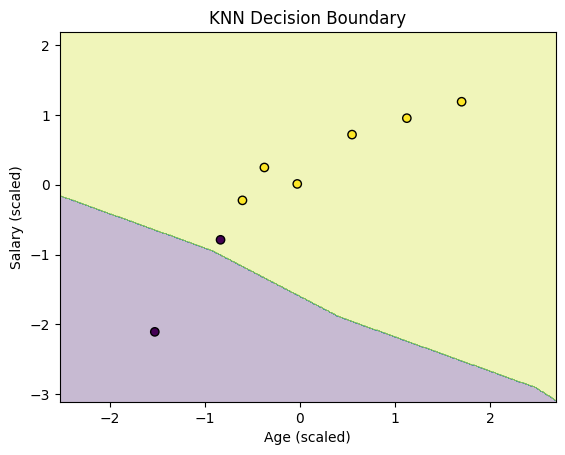


New Customer Prediction: [1]


C:\Users\LENOVO\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# ==============================
# KNN Customer Purchase Prediction
# ==============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 2. Load Dataset
df = pd.read_csv("customerpurchase.csv")

# 3. Feature Selection
X = df[['Age', 'Salary']]
y = df['Purchased']


# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 6. Train Model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)


# 7. Predictions
y_pred = model.predict(X_test)


# 8. Evaluation
print("===== Model Evaluation =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# 9. Visualize Decision Boundary (2D)
X_set = X_train
y_set = y_train.to_numpy()

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
    np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolor='k')
plt.title("KNN Decision Boundary")
plt.xlabel("Age (scaled)")
plt.ylabel("Salary (scaled)")
plt.show()


# 10. New Prediction
new_data = [[29, 52000]]
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("\nNew Customer Prediction:", prediction)